# Section B: Practical Task

### Task 1
**1. Implement an automated data ingestion pipeline using Pandas to load the UCI Heart Disease dataset and perform type-casting for categorical variables like 'sex', 'cp', and 'restecg'.**

In [25]:
import pandas as pd

In [26]:
df = pd.read_csv('heart_disease_uci.csv')

In [27]:
df.rename(columns={'num': 'target', 'thalch': 'thalach'}, inplace=True)

In [28]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [29]:
df['sex'] = df['sex'].astype('category')

In [30]:
df['cp'] = df['cp'].astype('category')

In [31]:
df['restecg'] = df['restecg'].astype('category')

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   id        920 non-null    int64   
 1   age       920 non-null    int64   
 2   sex       920 non-null    category
 3   dataset   920 non-null    object  
 4   cp        920 non-null    category
 5   trestbps  861 non-null    float64 
 6   chol      890 non-null    float64 
 7   fbs       830 non-null    object  
 8   restecg   918 non-null    category
 9   thalach   865 non-null    float64 
 10  exang     865 non-null    object  
 11  oldpeak   858 non-null    float64 
 12  slope     611 non-null    object  
 13  ca        309 non-null    float64 
 14  thal      434 non-null    object  
 15  target    920 non-null    int64   
dtypes: category(3), float64(5), int64(3), object(5)
memory usage: 96.7+ KB


In [33]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


---
### Task 2
**2. Execute a comprehensive outlier detection strategy on 'chol' (cholesterol) and 'thalach' (max heart rate) using the Interquartile Range (IQR) method and visualize the results via Boxplots.**

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

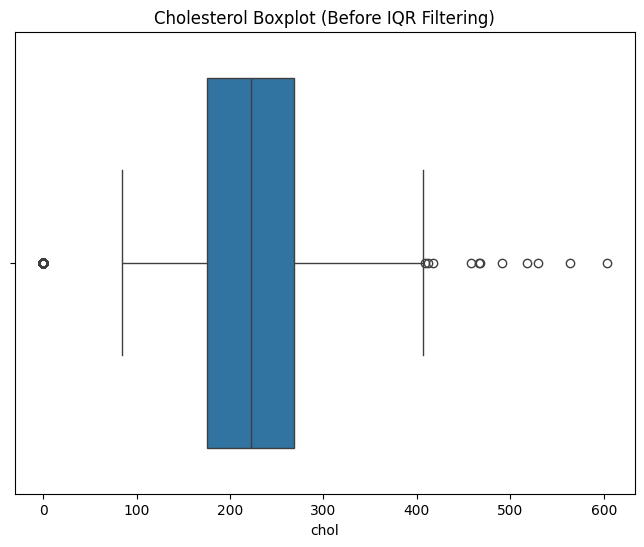

In [35]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['chol'])
plt.title('Cholesterol Boxplot (Before IQR Filtering)')
plt.show()

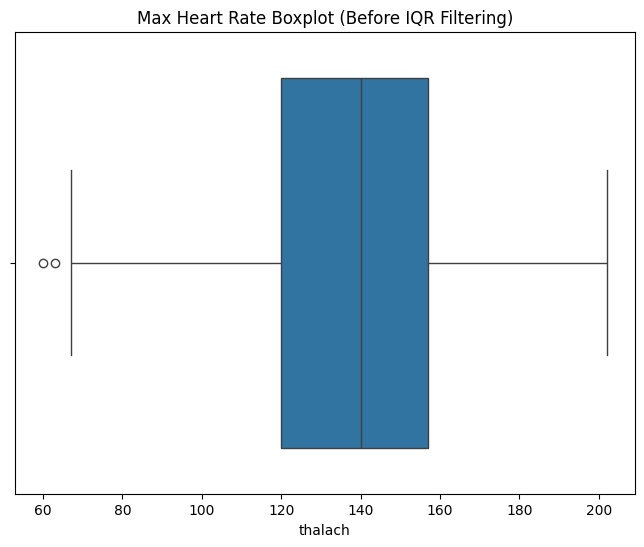

In [37]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['thalach'])
plt.title('Max Heart Rate Boxplot (Before IQR Filtering)')
plt.show()

In [38]:
def detect_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = dataframe[(dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)]
    return outliers

In [39]:
chol_outliers = detect_outliers_iqr(df, 'chol')

In [40]:
chol_outliers[['chol']]

,chol
48,417.0
152,564.0
181,409.0
373,412.0
434,468.0
...,...
818,0.0
819,0.0
822,0.0
839,0.0


In [42]:
thalach_outliers = detect_outliers_iqr(df, 'thalach')

In [44]:
thalach_outliers[['thalach']]

,thalach
631,60.0
677,63.0


---
### Task 3
**3. Conduct multivariate analysis using Seaborn Heatmaps to identify multi-collinearity between clinical features and determine which variables hold the strongest correlation with the target 'heart disease' label.**

In [45]:
numerical_df = df.select_dtypes(include=['int64', 'float64'])

In [46]:
correlation_matrix = numerical_df.corr()

In [47]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


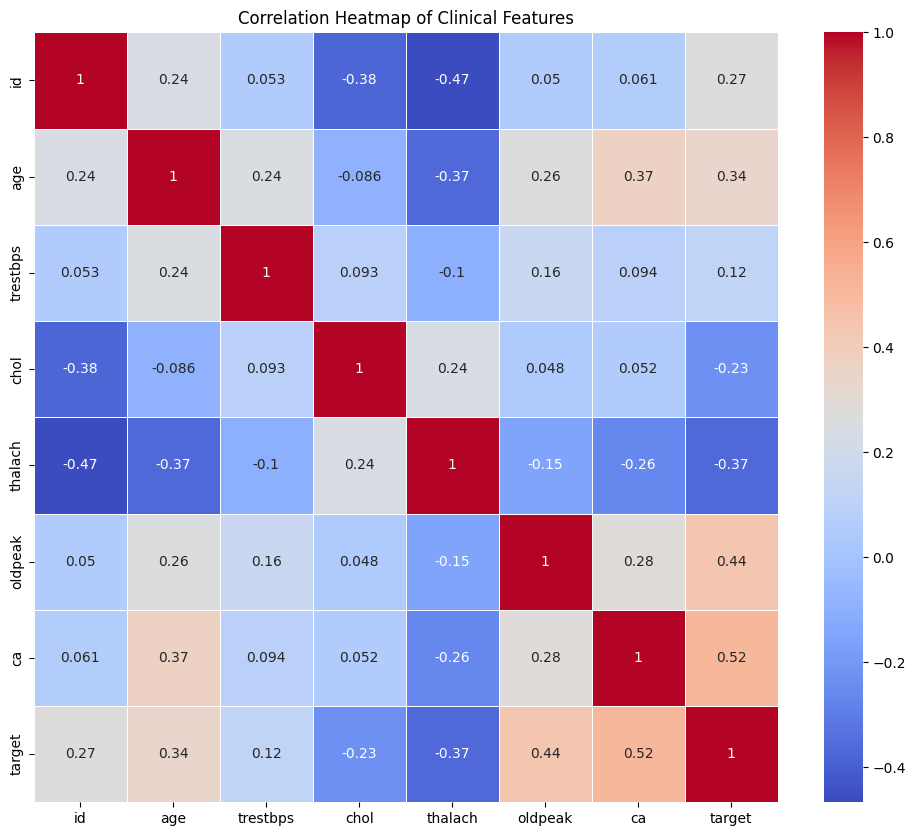

In [48]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Clinical Features')
plt.show()

In [49]:
target_correlations = correlation_matrix['target'].sort_values(ascending=False)

In [50]:
target_correlations

target      1.000000
ca          0.516216
oldpeak     0.443084
age         0.339596
id          0.273552
trestbps    0.122291
chol       -0.231547
thalach    -0.366265
Name: target, dtype: float64

---
### Task 4
**4. Develop a feature engineering script to normalize numerical data using StandardScaler and create derived features such as 'Age-adjusted Max Heart Rate' to improve predictive signal.**

In [51]:
from sklearn.preprocessing import StandardScaler

In [52]:
df['age_adjusted_max_hr'] = 220 - df['age']

In [53]:
df['hr_reserve'] = df['age_adjusted_max_hr'] - df['thalach']

In [54]:
df[['age', 'thalach', 'age_adjusted_max_hr', 'hr_reserve']].head()

,age,thalach,age_adjusted_max_hr,hr_reserve
0,63,150.0,157,7.0
1,67,108.0,153,45.0
2,67,129.0,153,24.0
3,37,187.0,183,-4.0
4,41,172.0,179,7.0


In [55]:
scaler = StandardScaler()

In [56]:
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'age_adjusted_max_hr', 'hr_reserve']

In [57]:
df[num_cols] = scaler.fit_transform(df[num_cols])

In [58]:
df[num_cols].head()

,age,trestbps,chol,thalach,oldpeak,age_adjusted_max_hr,hr_reserve
0,1.007386,0.675287,0.305908,0.480653,1.303159,-1.007386,-0.925494
1,1.432034,1.462483,0.784599,-1.140262,0.569611,-1.432034,0.650233
2,1.432034,-0.636705,0.269780,-0.329805,1.578239,-1.432034,-0.220563
3,-1.752828,-0.111908,0.459450,1.908602,2.403480,1.752828,-1.381625
4,-1.328180,-0.111908,0.043982,1.329704,0.477918,1.328180,-0.925494
